In [ ]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import json
from sklearn.decomposition import PCA

In [60]:
DISEASE = input("Disease: ")
OUTPUT_DIRECTORY = f"../output/{DISEASE}/"
NONE_OUTPUT_DIRECTORY = f"../output/NONE/"
DGIDB_DIRECTORY = f"../../Gen_Hypergraph/output/DGIDB_{DISEASE}/"
MSIGDB_DIRECTORY = "../../Gen_Hypergraph/output/MSigDB_Full/"

In [61]:
# load selected communities
with open(f"{OUTPUT_DIRECTORY}/result_communities_selected.pkl", "rb") as f:
    communities_selected = pickle.load(f)

In [62]:
with open(DGIDB_DIRECTORY + "gene_to_index.json", "r") as file:
    dgidb = json.load(file)
with open(MSIGDB_DIRECTORY + "gene_to_index.json", "r") as file:
    msigdb = json.load(file)
with open(OUTPUT_DIRECTORY + "gene_to_index_distinct.json", "r") as file:
    gene_to_index_distinct = json.load(file)

In [63]:
index_to_gene_distinct = {index: gene for gene, index in gene_to_index_distinct.items()}

In [64]:
# concatenate all genes from selected communities
all_genes = []
for community in communities_selected:
    all_genes.extend(community)
print(all_genes)

[11434, 11854, 7483, 16513, 11421, 10814, 6883, 6105, 12114, 3275, 10978, 14907, 7833, 13924, 6892, 5044, 12447, 6491, 11336, 14598, 18699, 6679, 4430, 4642, 7547, 16775, 9813, 5930, 6247, 3242, 11719, 8629, 550, 12481, 4127, 15376, 2904, 8606, 2331, 12546, 4656, 7326, 15965, 11214, 12645, 7046, 19526, 12097, 10642, 9003, 7162, 94, 10083, 12131, 21609, 15462, 8229, 9853, 2781, 5763, 8251, 6541, 10837, 11096, 11907, 8272, 16643, 6209, 10306, 9923, 4022, 10652, 10596, 8492, 12524, 8271, 5446, 11089, 8590, 11445, 5099, 4987, 8233, 11183, 10616, 13548, 15515, 7766, 6334, 15803, 9942, 14661, 14396, 1037, 8820, 8285, 13303, 6823, 14586, 13520, 11449, 12917, 12881, 8133, 12182, 4515, 5499, 9869, 14252, 8163, 17209, 8971, 7285, 9287, 10694, 10909, 10117, 14903, 16394, 17312, 7951, 7896, 6273, 8997, 12531, 14491, 10867, 8618, 7519, 17962, 8249, 11036, 9968, 6894, 6256, 9192, 8730, 8640, 12042, 4075, 9731, 4321, 917, 8047, 8204, 11250, 983, 7409, 13771, 7047, 3707, 5942, 4092, 12429, 11343, 1454

In [65]:
len(all_genes)

8193

In [66]:
all_genes_M = [msigdb.get(index_to_gene_distinct[gene_idx]) for gene_idx in all_genes]

In [67]:
# DGIDB-only genes are not in selected communities
len(all_genes_M)

8193

In [68]:
# with open(DGIDB_DIRECTORY + "gene_to_index.json", "r") as file:
#     dgidb = json.load(file)

In [69]:
# all_genes = list(range(len(dgidb)))

In [70]:
# load eigenvalues and eigenvectors
eigenvalues = np.load(OUTPUT_DIRECTORY + "/eigenvalues/vals_2.npy")
eigenvectors = np.load(OUTPUT_DIRECTORY + "/eigenvectors/vecs_2.npy")

In [71]:
# # load eigenvalues and eigenvectors single-layer
# eigenvalues_M = np.load(OUTPUT_DIRECTORY + "eigenvalues_M.npy")
# eigenvectors_P_M = np.load(OUTPUT_DIRECTORY + "eigenvectors_P_M.npy")

In [72]:
# load eigenvalues and eigenvectors single-layer
eigenvalues_M = np.load(NONE_OUTPUT_DIRECTORY + "/eigenvalues/vals_2.npy")
eigenvectors_M = np.load(NONE_OUTPUT_DIRECTORY + "/eigenvectors/vecs_2.npy")

In [73]:
# setting universal font sizes
font_size = 20
tick_font_size = 16
plt.rcParams.update({
    "font.size": font_size,          # base font size
    "axes.titlesize": font_size,
    "axes.labelsize": font_size,
    "xtick.labelsize": tick_font_size,
    "ytick.labelsize": tick_font_size,
    "legend.fontsize": font_size,
    "figure.titlesize": font_size,
    "legend.loc": 'best'
})


# PCA

In [137]:
# load ddm
ddm_both = np.load(f"{OUTPUT_DIRECTORY}/ddm_[2, 4, 6, 8].npy")

In [138]:
# load npy arrays for NONE
ddm_msigdb = np.load(f"{NONE_OUTPUT_DIRECTORY}/ddm_[2, 4, 6, 8].npy")

Explained variance ratio, both: [0.99048525 0.00311983]
Explained variance ratio, MSigDB: [0.9864321  0.00538749]


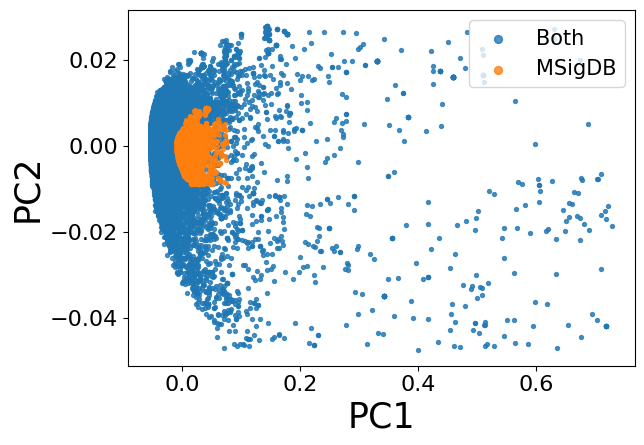

In [150]:
# ddm_both: diffusion distance matrix using both sources
# ddm_msigdb: diffusion distance matrix using MSigDB only

pca_both = PCA(n_components=2)
Phi_pca = pca_both.fit_transform(ddm_both)

pca_msigdb = PCA(n_components=2)
Phi_pca_M = pca_msigdb.fit_transform(ddm_msigdb)

print("Explained variance ratio, both:", pca_both.explained_variance_ratio_)
print("Explained variance ratio, MSigDB:", pca_msigdb.explained_variance_ratio_)

# === MODIFICATION START: remove outliers for visualization using percentile cutoff ===
pct = 99  # changed: keep points inside the 1st--99th percentile range

x1, y1 = Phi_pca[:, 0], Phi_pca[:, 1]
x2, y2 = Phi_pca_M[:, 0], Phi_pca_M[:, 1]

lo_x1, hi_x1 = np.percentile(x1, [100 - pct, pct])
lo_y1, hi_y1 = np.percentile(y1, [100 - pct, pct])

lo_x2, hi_x2 = np.percentile(x2, [100 - pct, pct])
lo_y2, hi_y2 = np.percentile(y2, [100 - pct, pct])

keep_both = (
    (x1 >= lo_x1) & (x1 <= hi_x1) &
    (y1 >= lo_y1) & (y1 <= hi_y1)
)

keep_msigdb = (
    (x2 >= lo_x2) & (x2 <= hi_x2) &
    (y2 >= lo_y2) & (y2 <= hi_y2)
)
# === MODIFICATION END ===

plt.figure(figsize=(7, 5))

# === MODIFICATION START: plot filtered PCA coordinates with labels ===
plt.scatter(
    Phi_pca[keep_both, 0],
    Phi_pca[keep_both, 1],
    s=8,
    alpha=0.8,
    label="Both"
)

plt.scatter(
    Phi_pca_M[keep_msigdb, 0],
    Phi_pca_M[keep_msigdb, 1],
    s=8,
    alpha=0.8,
    label="MSigDB"
)
# === MODIFICATION END ===

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc="upper right", fontsize=15, markerscale=2, frameon=True)
plt.tight_layout()
plt.savefig(f"../../Graphs/{DISEASE}/PCA_ddm_comparison.png")
plt.show()

# Top eigenvalues magnitude

In [74]:
top_eigenvalues = eigenvalues[:20]
top_eigenvalues_M = eigenvalues_M[:20]

In [75]:
font_size = 25
tick_font_size = 16
plt.rcParams.update({
    "font.size": font_size,          # base font size
    "axes.titlesize": font_size,
    "axes.labelsize": font_size,
    "xtick.labelsize": tick_font_size,
    "ytick.labelsize": tick_font_size,
    "legend.fontsize": font_size,
    "figure.titlesize": font_size,
    "legend.loc": 'best'
})


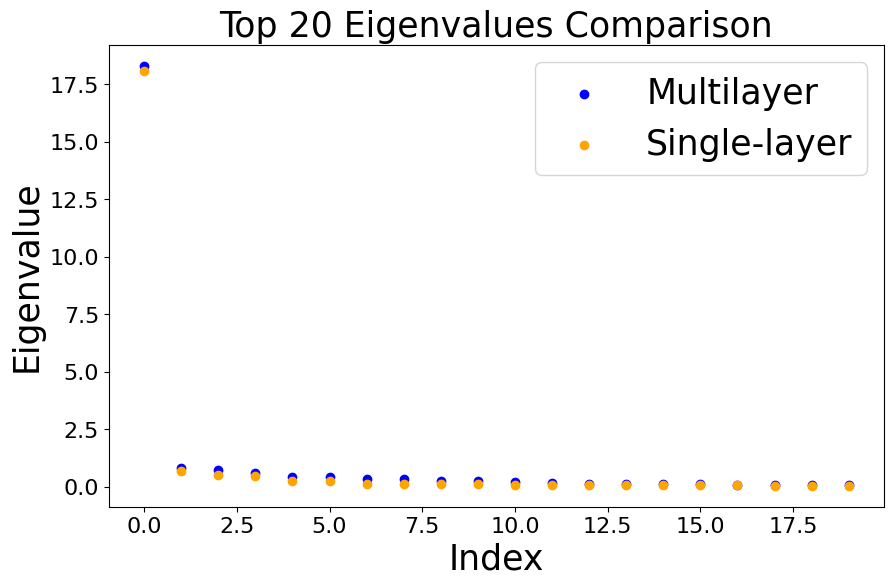

In [76]:
# plot eigenvalues comparison, dot plot, blue for multilayer, orange for single-layer
plt.figure(figsize=(10,6))
plt.scatter(range(len(top_eigenvalues)), top_eigenvalues, label="Multilayer", color='blue')
plt.scatter(range(len(top_eigenvalues_M)), top_eigenvalues_M, label="Single-layer", color='orange')
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.title("Top 20 Eigenvalues Comparison")
# put legend outside the plot
plt.legend()
plt.savefig(f"../../Graphs/{DISEASE}/top_20_eigenvalues_comparison.png")

# 2D eigenvalues embedding plots

In [77]:
lambda1,lambda2 = eigenvalues[1],eigenvalues[2]
phi1,phi2 = eigenvectors[:,1],eigenvectors[:,2]

In [78]:
lambda1_M,lambda2_M = eigenvalues_M[1],eigenvalues_M[2]
phi1_M,phi2_M = eigenvectors_M[:,1],eigenvectors_M[:,2]

In [79]:
def embedding(gene_idx,t):
    return np.array([(lambda1**t)*phi1[gene_idx], 
                     (lambda2**t)*phi2[gene_idx]])

In [80]:
def embedding_M(gene_idx,t):
    return np.array([(lambda1_M**t)*phi1_M[gene_idx], 
                     (lambda2_M**t)*phi2_M[gene_idx]])

In [81]:
embeddings = np.array([embedding(gene_idx, t=6) for gene_idx in all_genes])
print(embeddings)

[[-1.16350890e-03 -7.24306380e-05]
 [-1.16538044e-03 -1.21598727e-04]
 [-1.03805148e-03 -5.65658086e-05]
 ...
 [ 2.69243323e-02 -2.30591728e-03]
 [ 1.24877696e-02  7.43417470e-05]
 [ 1.13939467e-02 -4.34198381e-04]]


In [82]:
embeddings_M = np.array([embedding_M(gene_idx, t=6) for gene_idx in all_genes_M])
print(embeddings_M)

[[-1.40642483e-04 -5.20123732e-05]
 [-1.61099674e-04 -4.41177121e-05]
 [-1.15316444e-04 -2.71831936e-05]
 ...
 [ 2.81210093e-04  1.82339278e-05]
 [ 1.46861306e-04  4.83656600e-05]
 [-2.02361024e-04 -6.55165722e-05]]


In [83]:
x,y=embeddings[:,0],embeddings[:,1]

In [84]:
x_M,y_M=embeddings_M[:,0],embeddings_M[:,1]

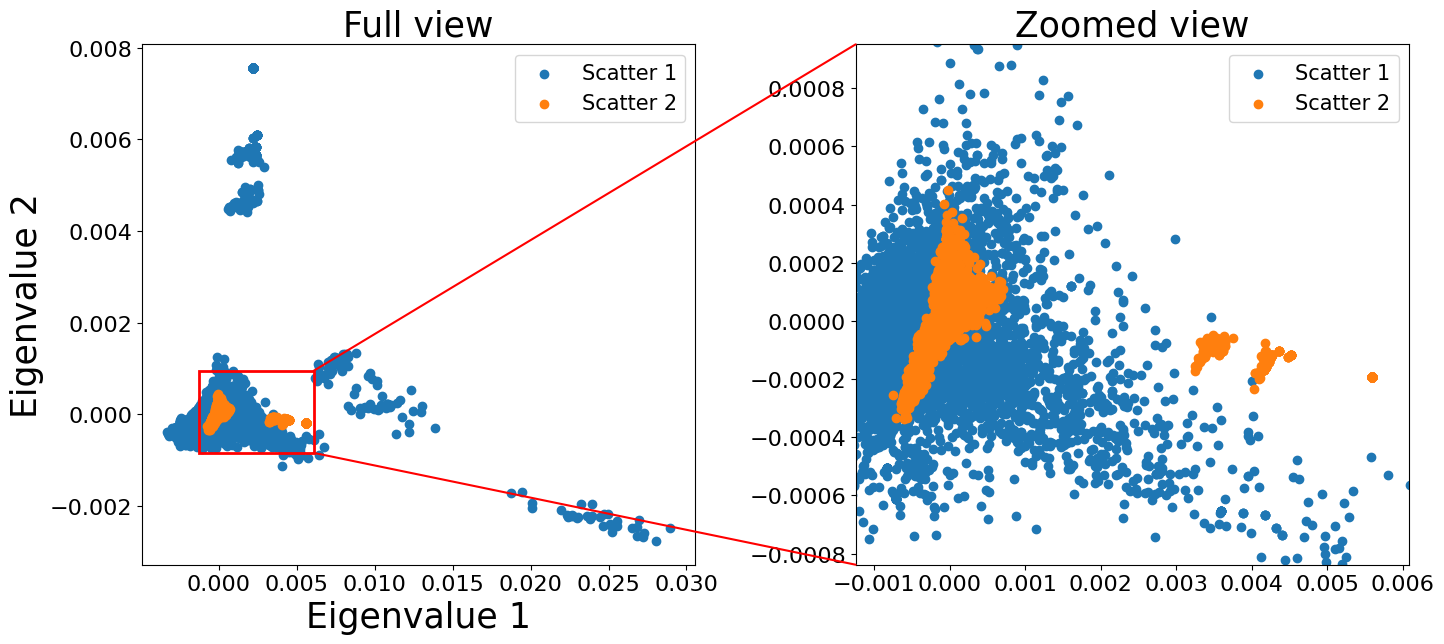

In [136]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, ConnectionPatch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# ----- full plot on the left -----
ax1.scatter(x, y, label="Scatter 1")  # unchanged
ax1.scatter(x_M, y_M, label="Scatter 2")  # unchanged
ax1.set_xlabel("Eigenvalue 1")
ax1.set_ylabel("Eigenvalue 2")
ax1.set_title("Full view")  # unchanged
ax1.legend(fontsize=15)  # changed: create the legend only once, after plotting, with smaller font

# ----- choose zoom region -----
x_min, x_max = min(x_M)-0.0005, max(x_M)+0.0005  # unchanged
y_min, y_max = min(y_M)-0.0005, max(y_M)+0.0005  # unchanged

# draw rectangle on left plot
rect = Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                 fill=False, edgecolor='red', linewidth=2)  # unchanged
ax1.add_patch(rect)  # unchanged

# ----- zoomed plot on the right -----
ax2.scatter(x, y, label="Scatter 1")  # unchanged
ax2.scatter(x_M, y_M, label="Scatter 2")  # unchanged
ax2.set_xlim(x_min, x_max)  # unchanged
ax2.set_ylim(y_min, y_max)  # unchanged
ax2.set_title("Zoomed view")  # unchanged
ax2.legend(fontsize=15)  # changed: actually create the right legend here, after plotting

# ----- connector lines between box and zoomed panel -----
con1 = ConnectionPatch(xyA=(x_max, y_max), coordsA=ax1.transData,
                       xyB=(x_min, y_max), coordsB=ax2.transData,
                       color="red", linewidth=1.5)  # unchanged
con2 = ConnectionPatch(xyA=(x_max, y_min), coordsA=ax1.transData,
                       xyB=(x_min, y_min), coordsB=ax2.transData,
                       color="red", linewidth=1.5)  # unchanged
fig.add_artist(con1)  # unchanged
fig.add_artist(con2)  # unchanged

plt.tight_layout()
plt.savefig(f"../../Graphs/{DISEASE}/eigen_embedding_comparison.png")
plt.show()

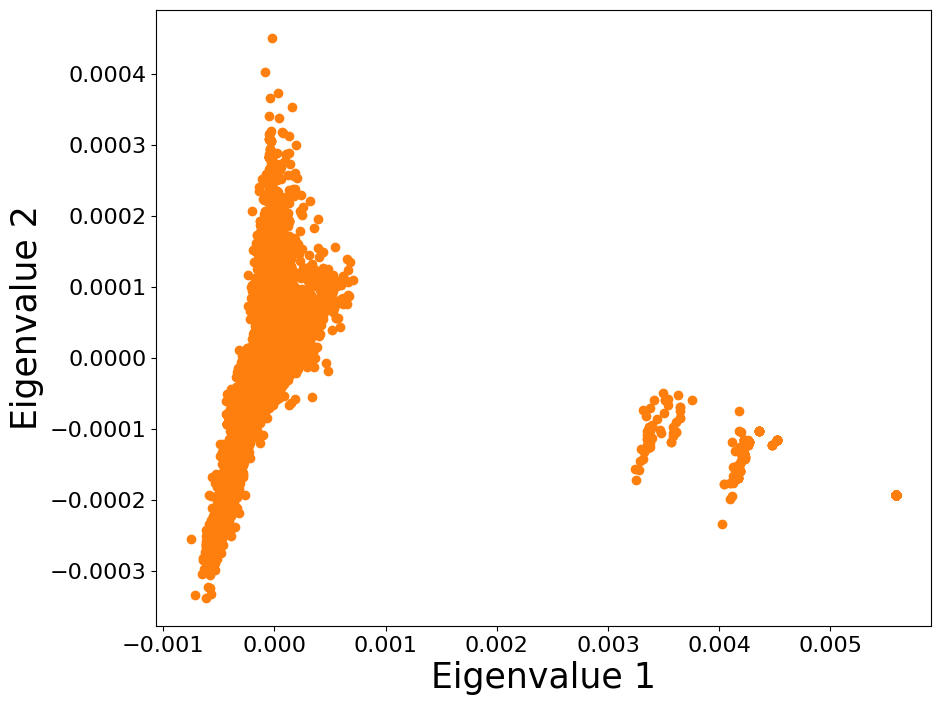

In [90]:
plt.figure(figsize=(10,8))
plt.scatter(x_M, y_M, color = '#ff7f0e', label="Single-layer")
plt.xlabel("Eigenvalue 1")
plt.ylabel("Eigenvalue 2")
plt.savefig(f"../../Graphs/{DISEASE}/eigen_embedding_single_layer.png")

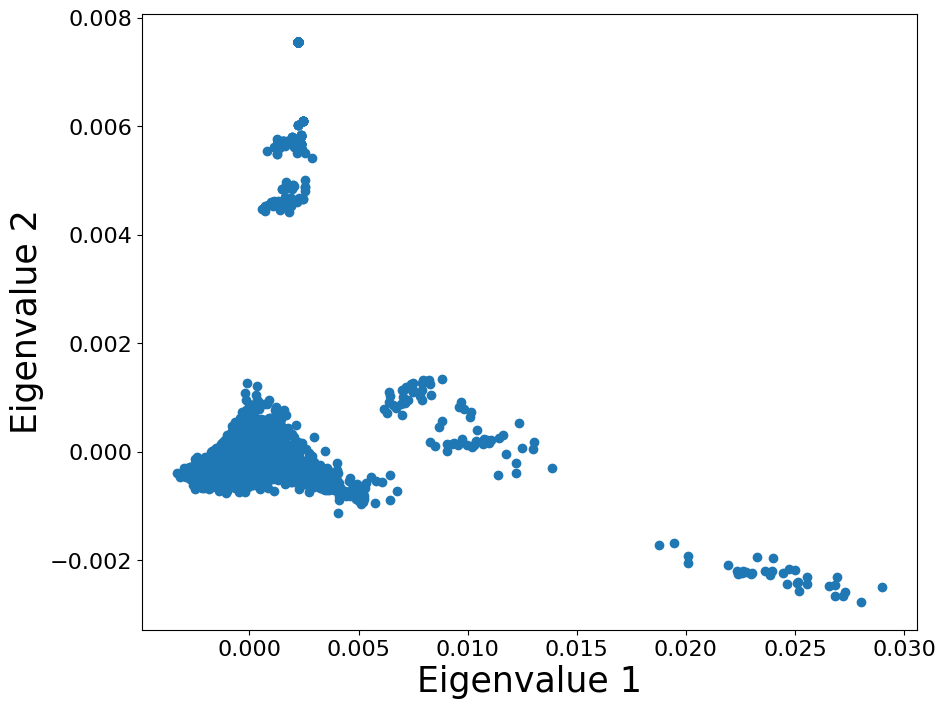

In [91]:
plt.figure(figsize=(10,8))
plt.scatter(x, y, color = '#1f77b4', label="Single-layer")
plt.xlabel("Eigenvalue 1")
plt.ylabel("Eigenvalue 2")
plt.savefig(f"../../Graphs/{DISEASE}/eigen_embedding_multi_layer.png")